In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D  
import figurefirst as fifi
import seaborn as sns
###
import sys
sys.path.insert(1, '../../../Code')
from PlotUtilities import *
from FeatureFunctions import *
from sklearn.feature_selection import f_classif


from tsfresh import defaults, extract_features
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import MinimalFCParameters, ComprehensiveFCParameters #
 
import umap

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler



# Set params and load FiFi template

In [2]:
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


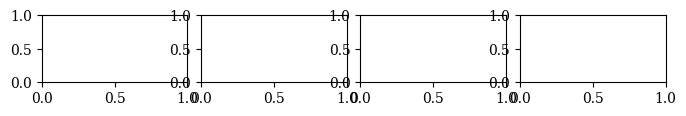

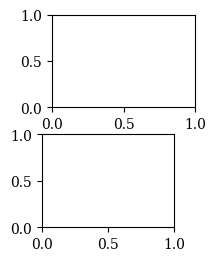

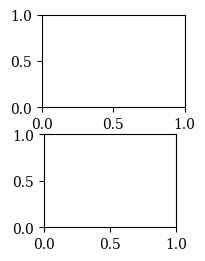

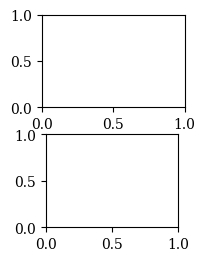

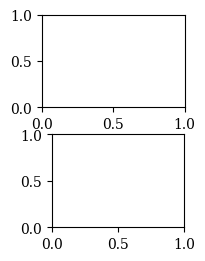

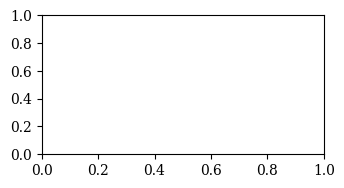

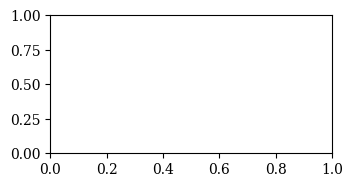

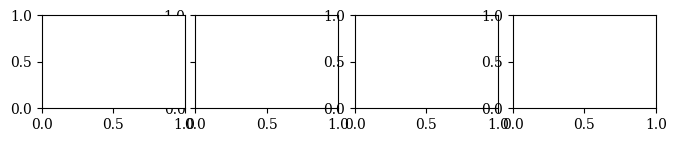

In [78]:
layout = fifi.svg_to_axes.FigureLayout('../f5_realvsreal.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])



# Laminar - Control

In [4]:
lam_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/training_laminar_df.hdf')



In [5]:
lam_df = get_normed_positions(lam_df)

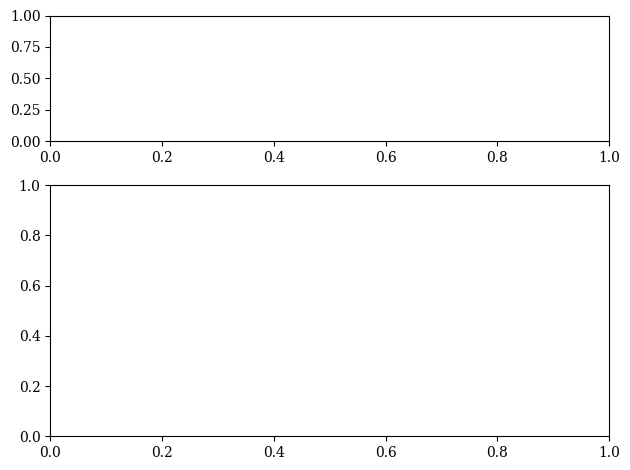

In [79]:
df1_left = lam_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
ax[0] = layout.axes[('A1', 'a1')]
ax[1] = layout.axes[('A1', 'a2')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
#X,Y = np.meshgrid(x,y)
#newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)

ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True,zorder=0)
ax[0].scatter(0,0, color='red', s=5)



a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True,zorder=0)
ax[1].scatter(0,0, color='red', s=5)



fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':5, 'bottom':5},   tick_length=3, linewidth=.5)
fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':5}, tick_length=3, linewidth=.5)

ax[0].set_xticklabels(['-0.25','0.0','0.25'])
ax[1].set_yticklabels(['-1','','0','','1'])
ax[1].set_xticklabels(['-1','','0','','1'])
fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

ax[0].set_xlabel('x position (m)')
ax[0].set_ylabel('y position (m)', labelpad=0)

ax[1].set_xlabel('x velocity (m/s)')
ax[1].set_ylabel('y velocity (m/s)', labelpad=0)
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].text(x=.3,y=0.2, s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['A1'], 'A1', cleartarget=True)

# Steady, low

In [7]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')


In [8]:
bottom_on_df['ground speed']= np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)

In [9]:
df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0]
df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0]


In [10]:
flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

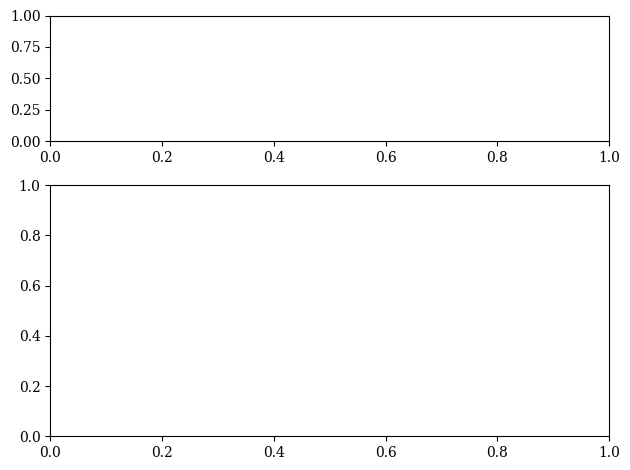

In [81]:
df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
ax[0] = layout.axes[('B1', 'b1')]
ax[1] = layout.axes[('B1', 'b2')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True, zorder=0)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)
ax[0].axis('off')
ax[1].axis('off')
ax[0].text(x=.3,y=0.2, s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['B1'], 'B1', cleartarget=True)


# Unsteady, low

In [12]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_top_laminar_09092024.hdf')

In [13]:
top_on_df['ground speed'] = np.sqrt(top_on_df['xvel']**2 + top_on_df['yvel']**2)

In [14]:
df_flash_top_on = top_on_df[top_on_df.duration>0]
df_sham_top_on =top_on_df[top_on_df.duration==0]

In [15]:
flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)


sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

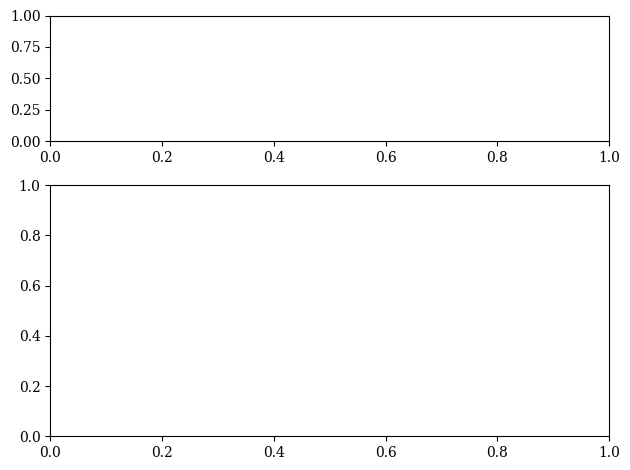

In [82]:
df1_left = flash_low_top_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
ax[0] = layout.axes[('C1', 'c1')]
ax[1] = layout.axes[('C1', 'c2')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True,zorder=0)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = nw_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


#fifi.mpl_functions.set_fontsize(ax[0], 6)
#fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].axis('off')
ax[1].axis('off')
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[0].text(x=.3,y=0.2, s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['C1'], 'C1', cleartarget=True)



# Still air

In [17]:
nw_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/training_nw_df.hdf')



In [18]:
nw_df = get_normed_positions(nw_df)

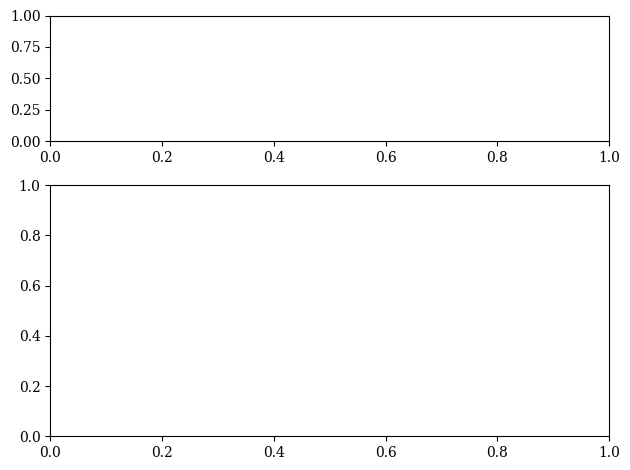

In [83]:
df1_left = nw_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
ax[0] = layout.axes[('D1', 'd1')]
ax[1] = layout.axes[('D1', 'd2')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True,zorder=0)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = nw_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)
ax[0].axis('off')
ax[1].axis('off')
ax[0].text(x=.3,y=0.2, s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['D1'], 'D1', cleartarget=True)



# Sample Trajectories

In [20]:
## example trajs:

### lam_df: '687_20220927_170437'
### flash_low_bottom_on: '27980_20240114_171954'
### flash_low_top_on: '8802_20240514_172126', 
### nw_df: '2088_20220815_162329'

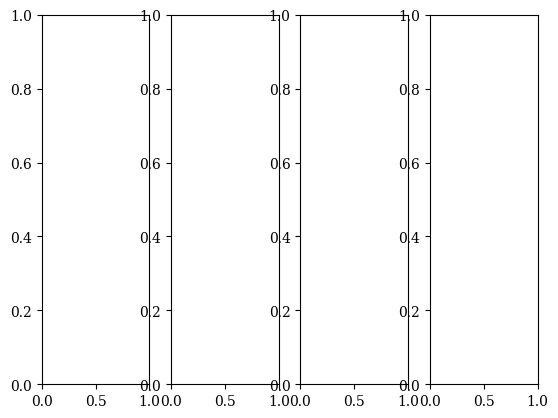

In [50]:
trajs= ['687_20220927_170437', '27980_20240114_171954','8802_20240514_172126', '2088_20220815_162329']
fig, ax= plt.subplots(ncols=4)
ax[0] = layout.axes[('T', 't1')]
ax[1] = layout.axes[('T', 't2')]
ax[2] = layout.axes[('T', 't3')]
ax[3] = layout.axes[('T', 't4')]

for i, df in enumerate([lam_df, flash_low_bottom_on, flash_low_top_on, nw_df]):
    get_subplot(df, trajs[i], ax=ax[i])


layout.append_figure_to_layer(layout.figures['T'], 'T', cleartarget=True)

# Generate Features

In [22]:
dfs = [lam_df,
       nw_df,
      flash_low_bottom_on, #4: 247
       flash_low_top_on, #5: 128
      flash_up_top_on, #6: 117
    flash_up_bottom_on, #7: 100
      ]


In [23]:
dfs = calculate_features(dfs, start_time=1100)

df # 0
Culled 6 trajectories
n trajs: 312
df # 1
Culled 1 trajectories
n trajs: 251
df # 2
Culled 45 trajectories
n trajs: 255
df # 3
Culled 88 trajectories
n trajs: 231
df # 4
Culled 20 trajectories
n trajs: 115
df # 5
Culled 7 trajectories
n trajs: 99


In [24]:
all_dfs = pd.concat(dfs)

In [25]:
X = extract_features(all_dfs[['xvel','yvel', 'normed_x_680', 'normed_y_680','obj_id_unique','time stamp']].dropna(), 
                         column_id='obj_id_unique', column_sort='time stamp',
                         default_fc_parameters=MinimalFCParameters(),
                         #default_fc_parameters=MinimalFCParameters(),
                     impute_function=impute)

# these are just the length of each time series, not relevant features

X = X.drop(columns=['xvel__length','yvel__length','normed_x_680__length','normed_y_680__length'])


2025-01-11 11:52:08,657 [WARNING] Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100%|█████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 107.32it/s]


In [26]:
df_features_list = []

cmap_real = plt.get_cmap('RdBu', 16) 


#  Steady: real -> Blues; sim -> green
# Unsteady: real -> orange; sim -> pink/brown

df_colors = [cmap_real(1),
             cmap_real(15),

             'darkorange',
            cmap_real(13),
             cmap_real(3),#cmap_real(6),
            cmap_real(11),]


df_labels = ['Laminar', #0
             'Still Air', #1
             'Steady, z < 0.25m', #2
             'Unsteady, z < 0.25m', #3
             'Steady, z > 0.25m', #4
             'Unsteady, z > 0.25m', #5
            ]

df_features_list = []


feature_names = ['circle_cross', 
                 'hull_area', 
                 'hull_roundness', 
                 'heading_derivative_absmean',
                 'heading_difference_sliding_absmean',]


for i, df in enumerate(dfs):
    df['dataset_name'] = df_labels[i]
    
    #df =df.assign(color=df.apply(lambda x: df_colors[i], 1))
    df_features = df.groupby('obj_id_unique')['dataset_name'].first()
    
    
    for feature_name in feature_names:
        df_tmp = np.abs( df.groupby('obj_id_unique')[feature_name].mean() )
        df_features = pd.concat([df_features, df_tmp], axis=1)
    df_features['class']=i
    df_features =df_features.assign(color=df_features.apply(lambda x: df_colors[i], 1))
    df_features_list.append(df_features)
    
df_features = pd.concat(df_features_list)

In [27]:
dfs_important_feats = df_features.join(X)

### remove irrelevent feats via Mann Whitney U test

In [28]:
training_data = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])].drop(columns=['dataset_name', 'color','class',])#+ irrel_mann)#+ irrel_feats)
y_classes =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['class'] 
df_pvalues_mann = calculate_relevance_table(training_data,y_classes, fdr_level=0.05, hypotheses_independent=False)
irrel_feats_mannu=list(df_pvalues_mann [df_pvalues_mann['p_value']>0.05].feature.values)

# UMAPs

In [51]:
training_data = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])].drop(columns=['dataset_name', 'color','class',] + irrel_feats_mannu).sort_index()
training_data  =StandardScaler().fit_transform(training_data.values)
y_classes =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['class'].sort_index() 
y_colors =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['color'].sort_index()

trained_model = umap.UMAP(n_neighbors=25, min_dist=0,
    random_state=3000, transform_seed=42).fit(training_data )

/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


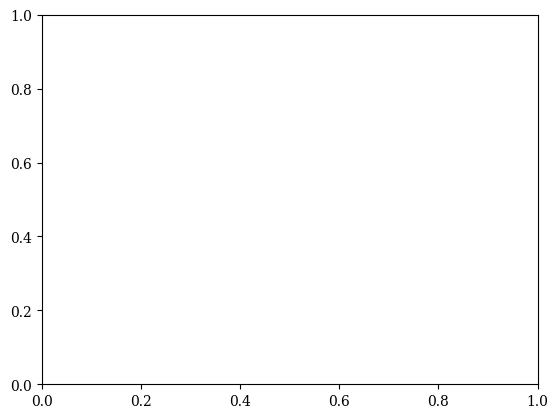

In [52]:
fig,ax=plt.subplots()

ax = layout.axes[('E1', 'e1')]
sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

ax.scatter(trained_model.embedding_[:, 0],trained_model.embedding_[:, 1], s= 2, c=y_colors,)


legend_labels=[]
legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=dfs_important_feats[dfs_important_feats.dataset_name=='Laminar'].color.iloc[0], markerfacecolor=dfs_important_feats[dfs_important_feats.dataset_name=='Laminar'].color.iloc[0], linestyle='', label=dfs_important_feats[dfs_important_feats.dataset_name=='Laminar'].dataset_name.iloc[0]))
legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=dfs_important_feats[dfs_important_feats.dataset_name=='Still Air'].color.iloc[0], markerfacecolor=dfs_important_feats[dfs_important_feats.dataset_name=='Still Air'].color.iloc[0], linestyle='', label=dfs_important_feats[dfs_important_feats.dataset_name=='Still Air'].dataset_name.iloc[0]))


#ax.legend(loc='upper left', handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
ax.set_xlim(2,12)
ax.set_ylim(7,13)
ax.set_aspect('equal')
#ax.set_rasterized(True)
ax.axis('off')

fifi.mpl_functions.set_fontsize(ax, 6)
layout.append_figure_to_layer(layout.figures['E1'], 'E1', cleartarget=True)

In [53]:
X_test = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m',
       'Unsteady, z > 0.25m', ])].sort_index().drop(columns=['dataset_name', 'color','class', ]+ irrel_feats_mannu)
X_test  =StandardScaler().fit_transform(X_test.values)

y_test =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m',
       'Unsteady, z > 0.25m', ])]['color'].sort_index()

test_embedding = trained_model.transform(X_test)


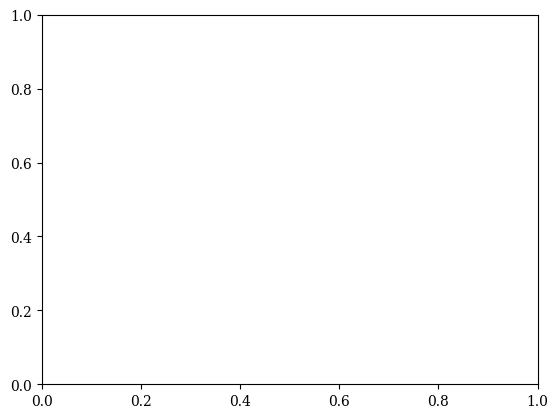

In [54]:
plottingdf = dfs_important_feats[dfs_important_feats.dataset_name.isin([ 'Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m',
       'Unsteady, z > 0.25m', ])].sort_index().copy()#.drop(columns=['dataset_name', 'color','class', ]+ irrel_feats+irrel_feats_lam).copy()
plottingdf['embedding_x'] = test_embedding[:, 0]
plottingdf['embedding_y'] =test_embedding[:, 1]



fig, ax = plt.subplots()

ax = layout.axes[('E2', 'e2')]
sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

for i in plottingdf['class'].unique():
    if "z > 0.25" in plottingdf[plottingdf['class']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['class']==i].embedding_x,plottingdf[plottingdf['class']==i].embedding_y, s= 2, c=plottingdf[plottingdf['class']==i].color, marker='d')
        legend_labels.append(Line2D([0], [0],marker='d', markersize=3, markeredgecolor=plottingdf[plottingdf['class']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['class']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['class']==i].dataset_name.iloc[0]))
    if "z < 0.25" in plottingdf[plottingdf['class']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['class']==i].embedding_x,plottingdf[plottingdf['class']==i].embedding_y, s= 2, c=plottingdf[plottingdf['class']==i].color)
        legend_labels.append(Line2D([0], [0],marker='.', markersize=3, markeredgecolor=plottingdf[plottingdf['class']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['class']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['class']==i].dataset_name.iloc[0]))
    
    
    #legend_labels.append(mpatches.Patch(color=plottingdf[plottingdf['class']==i].color.iloc[0], label=plottingdf[plottingdf['class']==i]['dataset_name'].iloc[0]))

ax.set_xlim(2,12)
ax.set_ylim(7,13)
ax.set_aspect('equal')

#ax.set_rasterized(True)
#ax.legend(bbox_to_anchor=[1,1], handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')
layout.append_figure_to_layer(layout.figures['E2'], 'E2', cleartarget=True)


# Sample Features

In [55]:

tmp = dfs_important_feats[dfs_important_feats.dataset_name=='Laminar']
e1 = pd.DataFrame(MinMaxScaler(feature_range=(-1,1)).fit_transform(tmp[['circle_cross', 'heading_difference_sliding_absmean', 'xvel__root_mean_square', 'normed_x_680__median', ]]
)).rename(columns={0:'circle_cross', 1:'heading_difference_sliding_absmean', 2:'xvel__root_mean_square', 3: 'normed_x_680__median'}).set_index(tmp.index)

tmp = dfs_important_feats[dfs_important_feats.dataset_name=='Still Air']
e2 = pd.DataFrame(MinMaxScaler(feature_range=(-1,1)).fit_transform(tmp[['circle_cross', 'heading_difference_sliding_absmean', 'xvel__root_mean_square', 'normed_x_680__median', ]].dropna()
)).rename(columns={0:'circle_cross', 1:'heading_difference_sliding_absmean', 2:'xvel__root_mean_square', 3: 'normed_x_680__median'}).set_index(tmp.index)


tmp = dfs_important_feats[dfs_important_feats.dataset_name=='Steady, z < 0.25m']
e3 = pd.DataFrame(MinMaxScaler(feature_range=(-1,1)).fit_transform(tmp[['circle_cross', 'heading_difference_sliding_absmean', 'xvel__root_mean_square', 'normed_x_680__median', ]]
)).rename(columns={0:'circle_cross', 1:'heading_difference_sliding_absmean', 2:'xvel__root_mean_square', 3: 'normed_x_680__median'}).set_index(tmp.index)


tmp = dfs_important_feats[dfs_important_feats.dataset_name=='Unsteady, z < 0.25m']
e4 = pd.DataFrame(MinMaxScaler(feature_range=(-1,1)).fit_transform(tmp[['circle_cross', 'heading_difference_sliding_absmean', 'xvel__root_mean_square', 'normed_x_680__median', ]]
)).rename(columns={0:'circle_cross', 1:'heading_difference_sliding_absmean', 2:'xvel__root_mean_square', 3: 'normed_x_680__median'}).set_index(tmp.index)



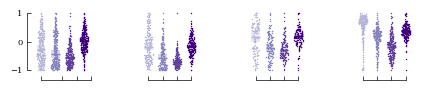

In [60]:
fig, ax= plt.subplots(ncols=4,  layout='tight')

ax[0] = layout.axes[('F', 'f1')]
ax[1] = layout.axes[('F', 'f2')]
ax[2] = layout.axes[('F', 'f3')]
ax[3] = layout.axes[('F', 'f4')]
# laminar
plot_several_features(e1,cmap='Purples',n=6, labels=[ ] ,ax=ax[0])
#still air
plot_several_features(e2,cmap='Purples',n=6, labels=[], ax=ax[3])
#steady
plot_several_features(e3,cmap='Purples',n=6, labels=[], ax=ax[1])
#unsteady
plot_several_features(e4,cmap='Purples',n=6, labels=[], ax=ax[2])


#labels=[ 'Hull \n roundness',  'Course direction \n difference','Circle \n cross', 'Median x \n Position',]
fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-1,0,1], xticks =[0,1,2,3],  spine_locations={'left':5, 'bottom':5, }, tick_length=3, linewidth=.5)
fifi.mpl_functions.set_fontsize(ax[0], 6)

#ax[0].set_aspect(.2)
#ax[1].set_aspect(.2)
#ax[2].set_aspect(.2)
#ax[3].set_aspect(.2)
layout.append_figure_to_layer(layout.figures['F'], 'F', cleartarget=True)


# Save Figure

In [84]:
layout.write_svg('f5_real_vs_real.svg')

# Save UMAP Model

In [36]:
# with pickle
import pickle

f_name = 'UMAP_trained.sav'
pickle.dump(trained_model, open(f_name, 'wb'))
